In [9]:
import numpy
from matplotlib import pyplot

In [ ]:
def model_spins(spin_count: int, T: float, step_count: int, B: float = 1, initial_towards = False) -> tuple[numpy.ndarray, numpy.ndarray]:
    spins = (1 if initial_towards else -1) * numpy.ones(spin_count)

    def magniticity():
        return numpy.sum(spins)

    def energy():
        return -B * magniticity()
    
    magniticities, energies = [], []
    for _ in range(step_count):
        magniticities.append(magniticity())

        current_energy = energy()
        energies.append(current_energy)

        switched = numpy.random.randint(0, len(spins))
        spins[switched] = -spins[switched]

        deltaEnergy = energy() - current_energy
        if deltaEnergy > 0 and numpy.random.random() > numpy.exp(-deltaEnergy / T):
            spins[switched] = -spins[switched]
    
    return numpy.array(magniticities), numpy.array(energies)

In [103]:
M, E = model_spins(1000, 273, 10000)

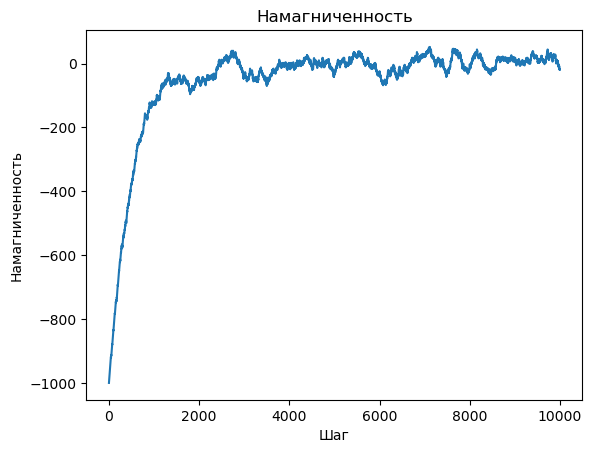

In [104]:
pyplot.plot(numpy.arange(len(M)), M)
pyplot.xlabel('Шаг')
pyplot.ylabel('Намагниченность')
pyplot.title('Намагниченность')
pyplot.show()

In [105]:
def analyze_average_magniticity(spin_count: int, Ts: numpy.ndarray, step_count: int,
                                B: float = 1, initial_towards = False) -> numpy.ndarray:
    averages = []
    for T in Ts:
        magniticities, _ = model_spins(spin_count, T, step_count, B, initial_towards)
        averages.append(numpy.average(magniticities[-step_count // 2:]))
    return numpy.array(averages)

In [119]:
# Ts = numpy.concatenate([numpy.arange(1, 100), numpy.arange(100, 1000, 10)])
Ts = numpy.arange(1, 100)
Ms = analyze_average_magniticity(1000, Ts, 10000)

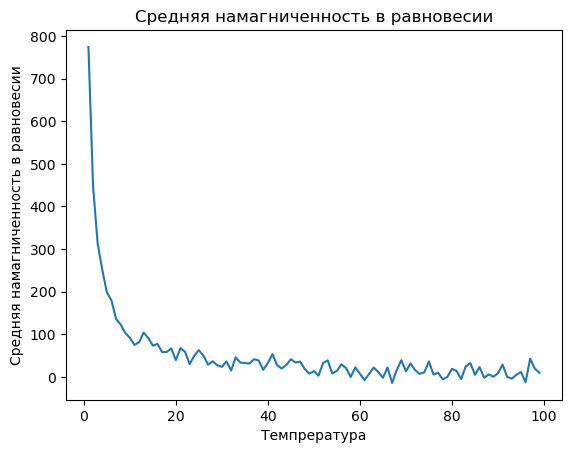

In [120]:
pyplot.plot(Ts, Ms)
pyplot.xlabel('Темпрература')
pyplot.ylabel('Средняя намагниченность в равновесии')
pyplot.title('Средняя намагниченность в равновесии')
pyplot.show()